In [4]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats
from endgame import hist2d

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [3]:
cd ..


/home/users/cornkle/pythonWorkspace/proj_CEH


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# VPD helper functions
# ------------------------------------------------------------

def calc_vpd_from_t_q(t, q, p_hpa=1000.):
    """
    Calculate vapour pressure deficit from temperature and specific humidity.

    t     : temperature, usually K. If values look like Celsius, code handles it.
    q     : specific humidity, usually kg/kg. If values look like g/kg, code converts.
    p_hpa : pressure in hPa. Use 1000 hPa as near-surface approximation unless you have psfc.

    returns VPD in hPa.
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    # If q looks like g/kg, convert to kg/kg
    q = np.where(q > 0.1, q / 1000., q)

    # If T looks like Celsius, convert to Kelvin
    t_k = np.where(t < 150, t + 273.15, t)
    t_c = t_k - 273.15

    # saturation vapour pressure, hPa
    es = 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))

    # actual vapour pressure from specific humidity, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1 - eps) * q)

    vpd = es - e
    return vpd


def add_vpd_to_abs_and_anom(abs_df, anom_df, suffix='1deg', p_hpa=1000.):
    """
    Adds VPD to both:
    - abs_df: storm-day absolute VPD
    - anom_df: storm-day VPD anomaly relative to that period's own climate

    Uses:
    storm climate T = storm absolute T - storm T anomaly
    storm climate q = storm absolute q - storm q anomaly
    """

    tvar = f't_srfc_{suffix}'
    qvar = f'q_srfc_{suffix}'
    outvar = f'vpd_srfc_{suffix}'

    # storm-day absolute VPD
    vpd_abs = calc_vpd_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)

    # reconstruct that period's local/day climatology for T and q
    t_clim = abs_df[tvar] - anom_df[tvar]
    q_clim = abs_df[qvar] - anom_df[qvar]

    # climatological VPD
    vpd_clim = calc_vpd_from_t_q(t_clim, q_clim, p_hpa=p_hpa)

    # add to dataframes
    abs_df[outvar] = vpd_abs
    anom_df[outvar] = vpd_abs - vpd_clim

    return abs_df, anom_df

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def calc_ef(lh, sh):
    """
    Evaporative fraction:
        EF = LH / (LH + SH)

    Assumes LH and SH are in the same units, e.g. W m-2.
    """
    lh = np.asarray(lh, dtype=float)
    sh = np.asarray(sh, dtype=float)

    denom = lh + sh
    ef = np.where(np.isclose(denom, 0) | np.isnan(denom), np.nan, lh / denom)
    return ef


def add_ef_to_abs_and_anom(abs_df, anom_df, suffix='1deg'):
    """
    Adds:
    - ef_1deg to abs_df  = EF from storm-day absolute LH/SH
    - ef_1deg to anom_df = EF_abs - EF_clim

    Do this separately for hist and fut.
    """

    lhvar = f'lh_{suffix}'
    shvar = f'sh_{suffix}'
    outvar = f'ef_{suffix}'

    # storm-day absolute EF
    ef_abs = calc_ef(abs_df[lhvar], abs_df[shvar])

    # reconstruct each period's climatological LH/SH
    lh_clim = abs_df[lhvar] - anom_df[lhvar]
    sh_clim = abs_df[shvar] - anom_df[shvar]

    # climatological EF
    ef_clim = calc_ef(lh_clim, sh_clim)

    # add derived absolute and derived anomaly
    abs_df[outvar] = ef_abs*100
    anom_df[outvar] = (ef_abs - ef_clim)*100

    return abs_df, anom_df

In [7]:
import numpy as np

def calc_thetae_from_t_q(t, q, p_hpa=925.):
    """
    Calculate equivalent potential temperature from temperature and specific humidity.

    t     : temperature, K or degC
    q     : specific humidity, kg/kg or g/kg
    p_hpa : pressure in hPa

    returns theta-e in K
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    # q: g/kg -> kg/kg if needed
    q = np.where(q > 0.1, q / 1000., q)

    # T: Celsius -> Kelvin if needed
    t_k = np.where(t < 150, t + 273.15, t)

    # avoid impossible q values
    q = np.where((q <= 0) | (q >= 1), np.nan, q)

    # mixing ratio, kg/kg
    r = q / (1. - q)

    # vapour pressure, hPa
    eps = 0.622
    e = (q * p_hpa) / (eps + (1. - eps) * q)
    e = np.where(e <= 0, np.nan, e)

    # dewpoint from vapour pressure, K
    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    # LCL temperature, K; Bolton-style approximation
    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    # potential temperature
    rd_cp = 0.2854
    theta = t_k * (1000. / p_hpa) ** rd_cp

    # equivalent potential temperature
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    return thetae

In [8]:
def add_thetae_to_abs_and_anom(abs_df, anom_df, suffix='1deg', p_hpa=925.):
    """
    Adds theta-e to storm-day absolute and anomaly dataframes.

    abs_df  : lhist or lfut
    anom_df : lahist or lafut

    Adds:
        thetae_calc_1deg to abs_df
        thetae_calc_1deg to anom_df

    thetae anomaly is calculated as:
        thetae_abs - thetae_clim
    """

    tvar = f't_srfc_{suffix}'
    qvar = f'q_srfc_{suffix}'
    outvar = f'thetae_{suffix}'

    thetae_abs = calc_thetae_from_t_q(abs_df[tvar], abs_df[qvar], p_hpa=p_hpa)

    t_clim = abs_df[tvar] - anom_df[tvar]
    q_clim = abs_df[qvar] - anom_df[qvar]

    thetae_clim = calc_thetae_from_t_q(t_clim, q_clim, p_hpa=p_hpa)

    abs_df[outvar] = thetae_abs
    anom_df[outvar] = thetae_abs - thetae_clim

    return abs_df, anom_df

In [9]:
import numpy as np

def saturation_vapour_pressure_hpa(t_k):
    """
    Saturation vapour pressure over liquid water, hPa.
    Input T in K.
    """
    t_c = t_k - 273.15
    return 6.112 * np.exp((17.67 * t_c) / (t_c + 243.5))


def calc_thetae_from_t_q(t, q, p_hpa=925.):
    """
    Equivalent potential temperature from T and specific humidity.

    t     : K or degC
    q     : kg/kg or g/kg
    p_hpa : hPa

    returns theta-e in K
    """

    t = np.asarray(t, dtype=float)
    q = np.asarray(q, dtype=float)

    q = np.where(q > 0.1, q / 1000., q)       # g/kg -> kg/kg if needed
    t_k = np.where(t < 150, t + 273.15, t)   # degC -> K if needed

    q = np.where((q <= 0) | (q >= 1), np.nan, q)

    r = q / (1. - q)

    eps = 0.622
    e = (q * p_hpa) / (eps + (1. - eps) * q)
    e = np.where(e <= 0, np.nan, e)

    ln_ratio = np.log(e / 6.112)
    td_c = (243.5 * ln_ratio) / (17.67 - ln_ratio)
    td_k = td_c + 273.15

    tlcl = 1. / (1. / (td_k - 56.) + np.log(t_k / td_k) / 800.) + 56.

    theta = t_k * (1000. / p_hpa) ** 0.2854
    thetae = theta * np.exp((3376. / tlcl - 2.54) * r * (1. + 0.81 * r))

    return thetae


def calc_thetaes_from_t(t, p_hpa=650.):
    """
    Saturated equivalent potential temperature from T and pressure.

    t     : K or degC
    p_hpa : hPa

    returns saturated theta-e in K
    """

    t = np.asarray(t, dtype=float)
    t_k = np.where(t < 150, t + 273.15, t)

    eps = 0.622

    es = saturation_vapour_pressure_hpa(t_k)
    es = np.where(es >= 0.99 * p_hpa, np.nan, es)

    rs = eps * es / (p_hpa - es)

    # saturated parcel: dewpoint = temperature, LCL approximately T
    tlcl = t_k

    theta = t_k * (1000. / p_hpa) ** 0.2854
    thetaes = theta * np.exp((3376. / tlcl - 2.54) * rs * (1. + 0.81 * rs))

    return thetaes

In [10]:
def add_cape_proxy_to_abs_and_anom(abs_df, anom_df, suffix='1deg',
                                   p_srfc_hpa=925., p_mid_hpa=650.):
    """
    Adds table-based two-level CAPE proxy:

        cape_proxy_calc = thetae_srfc - thetaes_mid

    to both absolute and anomaly dataframes.

    The anomaly is calculated as:

        cape_proxy_abs - cape_proxy_clim

    not from anomaly T/q directly.
    """

    t_s_var = f't_srfc_{suffix}'
    q_s_var = f'q_srfc_{suffix}'
    t_m_var = f't_mid_{suffix}'

    thetae_var  = f'thetae_calc_{suffix}'
    thetaes_var = f'thetaes_mid_calc_{suffix}'
    cape_var    = f'cape_proxy_calc_{suffix}'

    # storm-day absolute values
    thetae_s_abs = calc_thetae_from_t_q(abs_df[t_s_var], abs_df[q_s_var],
                                        p_hpa=p_srfc_hpa)

    thetaes_m_abs = calc_thetaes_from_t(abs_df[t_m_var],
                                        p_hpa=p_mid_hpa)

    cape_abs = thetae_s_abs - thetaes_m_abs

    # reconstruct period climatology
    t_s_clim = abs_df[t_s_var] - anom_df[t_s_var]
    q_s_clim = abs_df[q_s_var] - anom_df[q_s_var]
    t_m_clim = abs_df[t_m_var] - anom_df[t_m_var]

    thetae_s_clim = calc_thetae_from_t_q(t_s_clim, q_s_clim,
                                         p_hpa=p_srfc_hpa)

    thetaes_m_clim = calc_thetaes_from_t(t_m_clim,
                                         p_hpa=p_mid_hpa)

    cape_clim = thetae_s_clim - thetaes_m_clim

    # add to dataframes
    abs_df[thetae_var] = thetae_s_abs
    abs_df[thetaes_var] = thetaes_m_abs
    abs_df[cape_var] = cape_abs

    anom_df[thetae_var] = thetae_s_abs - thetae_s_clim
    anom_df[thetaes_var] = thetaes_m_abs - thetaes_m_clim
    anom_df[cape_var] = cape_abs - cape_clim

    return abs_df, anom_df

In [11]:
lhist_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_mean_table_JASMIN_3hmeansVersion_rainMask_fullBox_ICAPE.csv', index_col=0, low_memory=False).T
lfut_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_mean_table_JASMIN_3hmeansVersion_rainMask_fullBox_ICAPE.csv', index_col=0, low_memory=False).T

In [12]:
lahist_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_anom_table_JASMIN_3hmeansVersion_rainMask_fullBox.csv', index_col=0, low_memory=False).T
lafut_orig = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_anom_table_JASMIN_3hmeansVersion_rainMask_fullBox.csv', index_col=0, low_memory=False).T

In [13]:
for dat in [lahist_orig, lafut_orig, lhist_orig, lfut_orig]:
    for var in dat.keys():
        try:
            dat[var] = dat[var].astype(float)
        except:
            pass

In [14]:
print(len(lahist_orig))
print(len(lhist_orig))

24572
24282


In [15]:
keys = ["pmax", "area", "area_1mm"]
 
common = pd.merge(lahist_orig[keys].drop_duplicates(),lhist_orig[keys].drop_duplicates(),on=keys,how="inner")
lahist_orig = lahist_orig.merge(common, on=keys, how="inner")
lhist_orig = lhist_orig.merge(common, on=keys, how="inner")
 
common = pd.merge(lafut_orig[keys].drop_duplicates(),lfut_orig[keys].drop_duplicates(),on=keys,how="inner")
lafut_orig = lafut_orig.merge(common, on=keys, how="inner")
lfut_orig = lfut_orig.merge(common, on=keys, how="inner")

In [16]:
lahist, lafut, lhist, lfut= [df.copy() for df in (lahist_orig, lafut_orig, lhist_orig, lfut_orig)]

In [17]:
len(lahist)

20014

In [18]:
len(lhist)

20014

In [19]:
np.unique(lahist['month'])

array([7., 8., 9.])

In [20]:
np.unique(lhist['hour'])

array([17., 18., 19.])

In [21]:
lahist['area_1mm'].min()*4.4**2

19.360000000000003

In [22]:
lahist['pmax'].min()

0.4134321472886568

In [23]:
lahist['shear_fullBox'].max()

13.874670028686523

In [24]:
dtag = '2deg'

In [25]:
lhist, lahist = add_vpd_to_abs_and_anom(lhist, lahist, suffix=dtag, p_hpa=925.)
lfut,  lafut  = add_vpd_to_abs_and_anom(lfut,  lafut,  suffix=dtag, p_hpa=925.)

In [26]:
lhist, lahist = add_ef_to_abs_and_anom(lhist, lahist, suffix=dtag)
lfut,  lafut  = add_ef_to_abs_and_anom(lfut,  lafut,  suffix=dtag)

In [27]:
lhist, lahist = add_thetae_to_abs_and_anom(lhist, lahist, suffix=dtag, p_hpa=925.)
lfut,  lafut  = add_thetae_to_abs_and_anom(lfut,  lafut,  suffix=dtag, p_hpa=925.)

In [28]:
lhist, lahist = add_cape_proxy_to_abs_and_anom(lhist, lahist, suffix=dtag, p_srfc_hpa=925., p_mid_hpa=650.)

lfut, lafut = add_cape_proxy_to_abs_and_anom(lfut, lafut, suffix=dtag, p_srfc_hpa=925., p_mid_hpa=650.)

In [29]:
print(len(lhist),len(lahist))

20014 20014


In [30]:
print(list(lafut.keys()))

['tcwv_0.25deg', 'tcwv_1deg', 'tcwv_2deg', 'tcwv_fullBox', 'sh_0.25deg', 'sh_1deg', 'sh_2deg', 'sh_fullBox', 'lh_0.25deg', 'lh_1deg', 'lh_2deg', 'lh_fullBox', 't2_0.25deg', 't2_1deg', 't2_2deg', 't2_fullBox', 'q2_0.25deg', 'q2_1deg', 'q2_2deg', 'q2_fullBox', 'shear_0.25deg', 'shear_1deg', 'shear_2deg', 'shear_fullBox', 'u_mid_0.25deg', 'u_mid_1deg', 'u_mid_2deg', 'u_mid_fullBox', 'u_srfc_0.25deg', 'u_srfc_1deg', 'u_srfc_2deg', 'u_srfc_fullBox', 'v_mid_0.25deg', 'v_mid_1deg', 'v_mid_2deg', 'v_mid_fullBox', 'v_srfc_0.25deg', 'v_srfc_1deg', 'v_srfc_2deg', 'v_srfc_fullBox', 'q_mid_0.25deg', 'q_mid_1deg', 'q_mid_2deg', 'q_mid_fullBox', 't_mid_0.25deg', 't_mid_1deg', 't_mid_2deg', 't_mid_fullBox', 't_srfc_0.25deg', 't_srfc_1deg', 't_srfc_2deg', 't_srfc_fullBox', 'q_srfc_0.25deg', 'q_srfc_1deg', 'q_srfc_2deg', 'q_srfc_fullBox', 'geoH_srfc_0.25deg', 'geoH_srfc_1deg', 'geoH_srfc_2deg', 'geoH_srfc_fullBox', 'lsRain_noon_0.25deg', 'lsRain_noon_1deg', 'lsRain_noon_2deg', 'lsRain_noon_fullBox', 'lw

In [31]:
lahist = lahist[(lhist['pmax']>=1) ]
lhist = lhist[(lhist['pmax']>=1) ]

lafut = lafut[(lfut['pmax']>=1) ]
lfut = lfut[(lfut['pmax']>=1) ]

In [32]:
print(len(lhist),len(lahist))

19894 19894


SM_2deg dclim: -2.7417392092629473 danom: -1.1673832119152694 dstorm: -3.9091224211782176
sh_2deg dclim: 19.207658465050798 danom: 14.275068341380662 dstorm: 33.48272680643146
lh_2deg dclim: -25.074236846895758 danom: -23.395338527107178 dstorm: -48.469575374002915
ef_2deg dclim: -5.900537782817686 danom: -4.324730676970991 dstorm: -10.22526845978868
sw_net_2deg dclim: -16.10628414507198 danom: -7.203362679855758 dstorm: -23.309646824927768
t_srfc_2deg dclim: 5.721138543644656 danom: 0.28877374264184985 dstorm: 6.0099122862865215
q_srfc_2deg dclim: 0.004634240672248121 danom: 0.00023328657963338315 dstorm: 0.0048675272518815035
tcwv_2deg dclim: 19.141270572546745 danom: 1.6279752185745098 dstorm: 20.76924579112125
vpd_srfc_2deg dclim: 6.103025691970483 danom: 0.5929040653637622 dstorm: 6.695929757334245
div_2deg dclim: -1.601937042557704e-06 danom: -2.8464035270767337e-06 dstorm: -4.448340569634438e-06


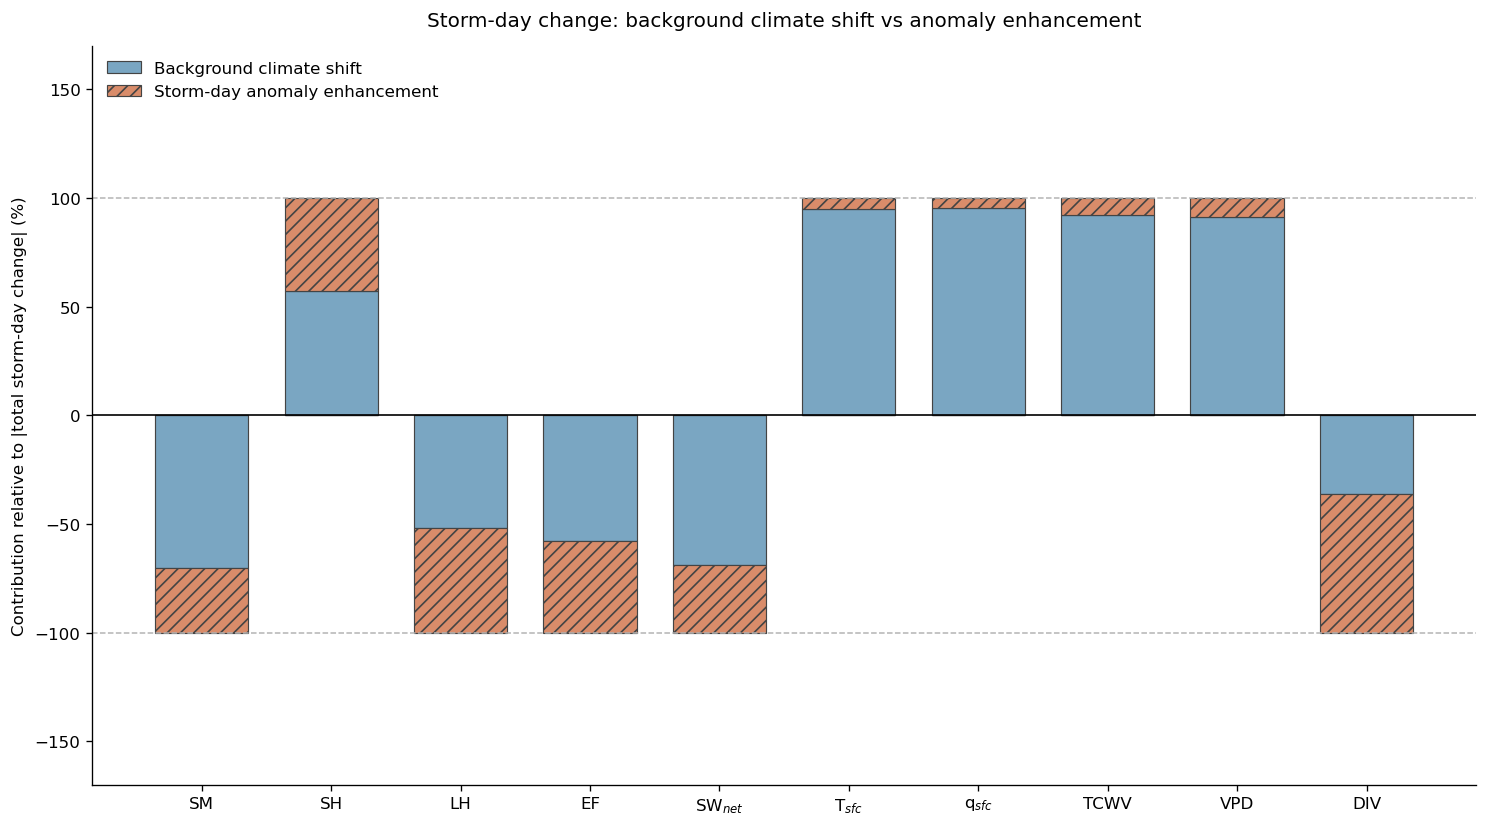

In [35]:
fig, ax = plt.subplots(figsize=(12.5, 7), dpi=120)

clim = []
anom = []

varts = ['SM_2deg',
         'sh_2deg', 'lh_2deg', 'ef_2deg', 'sw_net_2deg',
         't_srfc_2deg',
         'q_srfc_2deg', 'tcwv_2deg', 'vpd_srfc_2deg',
         'div_2deg']

lab = {'SM_2deg': 'SM',
       'sh_2deg': 'SH',
       'lh_2deg': 'LH',
       'ef_2deg': 'EF',
       'sw_net_2deg': 'SW$_{net}$',
       't_srfc_2deg': 'T$_{sfc}$',
       'q_srfc_2deg': 'q$_{sfc}$',
       'tcwv_2deg': 'TCWV',
       'vpd_srfc_2deg': 'VPD',
       'div_2deg': 'DIV'}

for v in varts:

    stormhist = np.nanmean(lhist[v].dropna())
    stormfut  = np.nanmean(lfut[v].dropna())

    anohist = np.nanmean(lahist[v].dropna())
    anofut  = np.nanmean(lafut[v].dropna())

    climhist = stormhist - anohist
    climfut  = stormfut - anofut

    dstorm = stormfut - stormhist
    dclim  = climfut - climhist
    danom  = anofut - anohist

    print(v, 'dclim:', dclim, 'danom:', danom, 'dstorm:', dstorm)

    if np.isclose(dstorm, 0):
        clim.append(np.nan)
        anom.append(np.nan)
    else:
        clim.append(dclim / np.abs(dstorm) * 100.)
        anom.append(danom / np.abs(dstorm) * 100.)

x = np.arange(len(varts))
xticks = [lab[v] for v in varts]

clim = np.array(clim)
anom = np.array(anom)

# positive and negative pieces for correct signed stacking
clim_pos = np.where(clim > 0, clim, 0)
clim_neg = np.where(clim < 0, clim, 0)

anom_pos = np.where(anom > 0, anom, 0)
anom_neg = np.where(anom < 0, anom, 0)

c_clim = '#7AA6C2'
c_anom = '#D98C6A'
edge = '#444444'

ax.bar(x, clim_pos, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7,
       label='Background climate shift')
ax.bar(x, clim_neg, width=0.72, color=c_clim, edgecolor=edge, linewidth=0.7)

ax.bar(x, anom_pos, width=0.72, bottom=clim_pos, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///', label='Storm-day anomaly enhancement')
ax.bar(x, anom_neg, width=0.72, bottom=clim_neg, color=c_anom, edgecolor=edge,
       linewidth=0.7, hatch='///')

ax.axhline(0, color='k', lw=1.0)
ax.axhline(100, color='0.7', lw=0.9, ls='--')
ax.axhline(-100, color='0.7', lw=0.9, ls='--')

ax.set_xticks(x)
ax.set_xticklabels(xticks)
ax.set_ylabel('Contribution relative to |total storm-day change| (%)')
ax.set_title('Storm-day change: background climate shift vs anomaly enhancement', pad=12)

ax.set_ylim(-170, 170)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.show()